# Project 3: Portfolio Optimization

**Author:** Eugenio Mandalà  
**Date:** March 2026

## Objective
Find the **optimal capital allocation** across 10 stocks that maximizes 
the Sharpe Ratio — the best possible return per unit of risk.

## Stocks Selected
| Ticker | Company | Sector |
|--------|---------|--------|
| AAPL | Apple | Tech |
| NVDA | Nvidia | Semiconductors |
| JPM | JPMorgan Chase | Finance |
| JNJ | Johnson & Johnson | Healthcare |
| TLT | US Bonds ETF | Fixed Income |
| MSFT | Microsoft | Tech |
| XOM | ExxonMobil | Energy |
| GLD | Gold ETF | Commodities |
| AMZN | Amazon | Consumer/Tech |
| UNH | UnitedHealth | Healthcare |

## Key Concepts
- **Sharpe Ratio** → Return / Risk — higher is better
- **Efficient Frontier** → curve of all optimal portfolios
- **Diversification** → combining low-correlation assets reduces risk

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from pypfopt import EfficientFrontier, risk_models, expected_returns

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2]:
# Download historical data for all 10 assets
tickers = ['AAPL', 'NVDA', 'JPM', 'JNJ', 'TLT',
           'MSFT', 'XOM', 'GLD', 'AMZN', 'UNH']

data = yf.download(tickers, start="2020-01-01",
                   end="2024-01-01", auto_adjust=True, progress=False)['Close']

print(f"✅ Downloaded data for {len(tickers)} assets")
print(f"   Period: 2020-2024 | {len(data)} trading days")
data.tail()

✅ Downloaded data for 10 assets
   Period: 2020-2024 | 1006 trading days


Ticker,AAPL,AMZN,GLD,JNJ,JPM,MSFT,NVDA,TLT,UNH,XOM
Date,,,,,,,,,,
2023-12-22,191.609467,153.419998,190.270004,145.440430,159.387573,368.236603,48.802814,90.263763,496.119415,94.430145
2023-12-26,191.065125,153.410004,191.720001,146.076614,160.330170,368.315308,49.251560,90.520409,495.852478,94.643265
2023-12-27,191.164093,153.339996,192.589996,146.273071,161.291855,367.735260,49.389488,92.124382,498.484100,94.198502
2023-12-28,191.589691,153.380005,191.470001,146.488251,162.148773,368.924774,49.494427,91.455315,500.496094,92.836388
2023-12-29,190.550461,151.940002,191.169998,146.637955,161.958344,369.671936,49.494427,90.630386,501.993042,92.641800


In [3]:
# Calculate expected returns and covariance matrix
mu = expected_returns.mean_historical_return(data)
S  = risk_models.sample_cov(data)

print("✅ Expected Annual Returns:")
for ticker, ret in mu.items():
    print(f"   {ticker:<6} {ret:.2%}")

✅ Expected Annual Returns:
   AAPL   27.46%
   AMZN   12.53%
   GLD    7.37%
   JNJ    4.58%
   JPM    8.03%
   MSFT   24.93%
   NVDA   69.95%
   TLT    -5.81%
   UNH    17.57%
   XOM    14.86%


## Portfolio Optimization — Maximum Sharpe Ratio

In [5]:
# Find optimal weights that maximize Sharpe Ratio
ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()

print("✅ Optimal Portfolio Weights:")
print("-" * 35)
for ticker, weight in cleaned_weights.items():
    if weight > 0:
        print(f"   {ticker:<6} {weight:.2%}")

print("\n📊 Portfolio Performance:")
ef.portfolio_performance(verbose=True)

✅ Optimal Portfolio Weights:
-----------------------------------
   GLD    41.00%
   NVDA   48.74%
   UNH    5.77%
   XOM    4.49%

📊 Portfolio Performance:
Expected annual return: 38.8%
Annual volatility: 29.2%
Sharpe Ratio: 1.33


(np.float64(0.3879465415829522),
 np.float64(0.29187226281293827),
 np.float64(1.3291654980986947))

## Figure 1 — Optimal Portfolio Weights

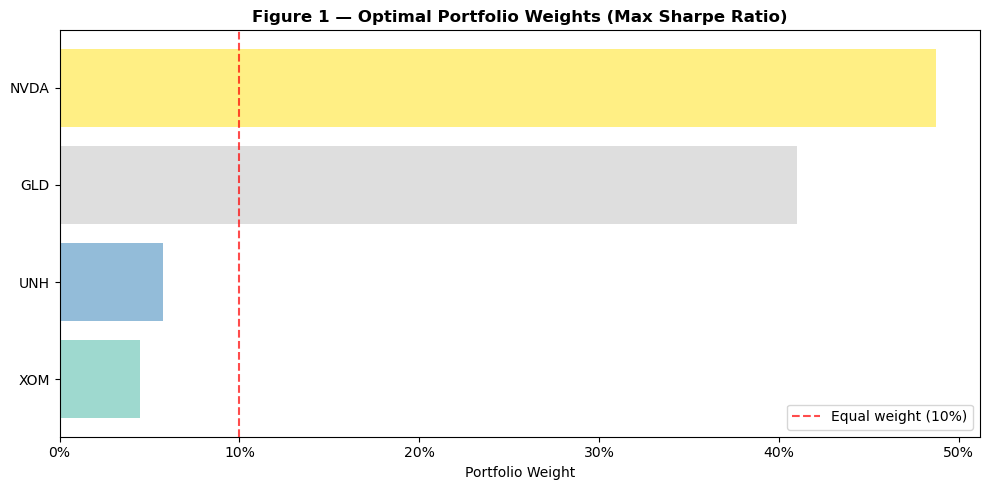

In [6]:
# Plot optimal weights
weights_df = pd.DataFrame.from_dict(cleaned_weights, 
                                     orient='index', 
                                     columns=['Weight'])
weights_df = weights_df[weights_df['Weight'] > 0].sort_values('Weight', ascending=True)

colors = plt.cm.Set3(np.linspace(0, 1, len(weights_df)))

plt.figure(figsize=(10, 5))
plt.barh(weights_df.index, weights_df['Weight'], color=colors, alpha=0.85)
plt.xlabel('Portfolio Weight')
plt.title('Figure 1 — Optimal Portfolio Weights (Max Sharpe Ratio)', 
          fontweight='bold')
plt.axvline(x=1/10, color='red', linestyle='--', 
            label='Equal weight (10%)', alpha=0.7)
plt.legend()
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

## Figure 2 — Correlation Matrix

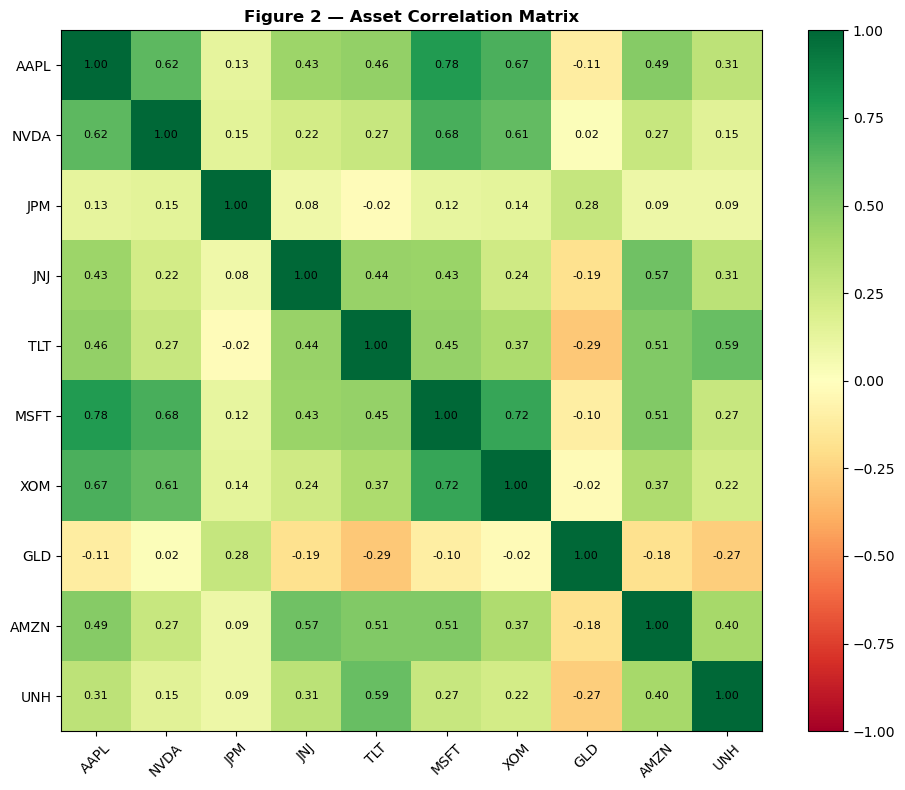

In [7]:
# Plot correlation matrix
returns = data.pct_change().dropna()
corr_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im)

ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers, rotation=45)
ax.set_yticklabels(tickers)

for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}',
                ha='center', va='center', fontsize=8,
                color='black')

ax.set_title('Figure 2 — Asset Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## Figure 3 — Efficient Frontier

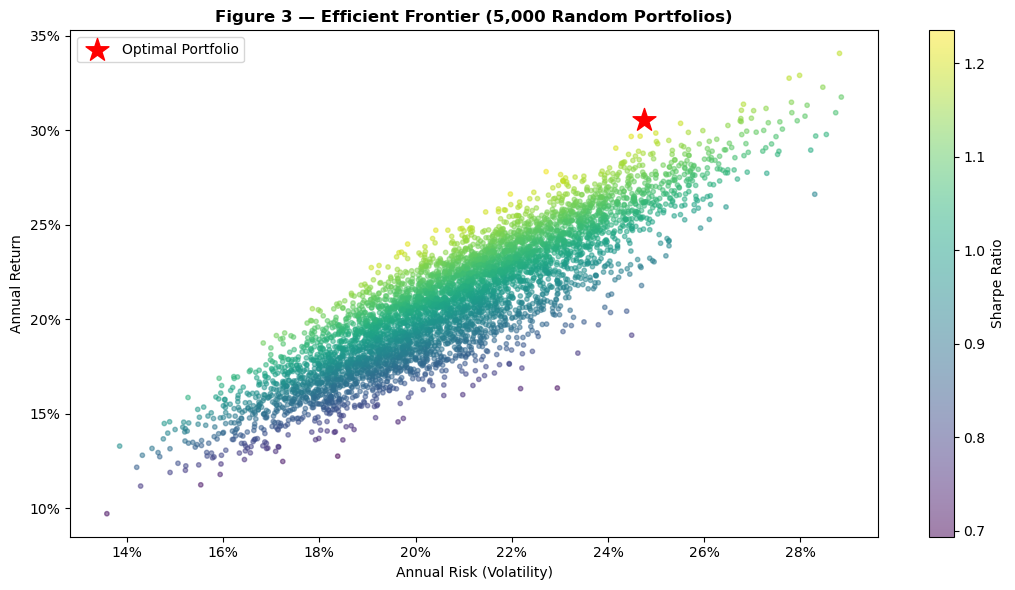


⭐ Optimal Portfolio:
   Return:       30.56%
   Risk:         24.74%
   Sharpe Ratio: 1.24


In [9]:
# Plot Efficient Frontier with Monte Carlo simulation
returns_annual = returns.mean() * 252
cov_annual = returns.cov() * 252

# Simulate 5000 random portfolios
n_portfolios = 5000
results = np.zeros((3, n_portfolios))

for i in range(n_portfolios):
    w = np.random.random(len(tickers))
    w /= w.sum()
    
    port_return = np.dot(w, returns_annual)
    port_risk   = np.sqrt(np.dot(w.T, np.dot(cov_annual, w)))
    sharpe      = port_return / port_risk
    
    results[0, i] = port_risk
    results[1, i] = port_return
    results[2, i] = sharpe

# Find optimal portfolio
max_sharpe_idx = results[2].argmax()

plt.figure(figsize=(11, 6))
scatter = plt.scatter(results[0], results[1], 
                      c=results[2], cmap='viridis', 
                      alpha=0.5, s=10)
plt.colorbar(scatter, label='Sharpe Ratio')

# Fix: marker='*' instead of star_marker='*'
plt.scatter(results[0, max_sharpe_idx], results[1, max_sharpe_idx],
            color='red', s=300, marker='*',
            label='Optimal Portfolio', zorder=5)

plt.xlabel('Annual Risk (Volatility)')
plt.ylabel('Annual Return')
plt.title('Figure 3 — Efficient Frontier (5,000 Random Portfolios)', 
          fontweight='bold')
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n⭐ Optimal Portfolio:")
print(f"   Return:       {results[1, max_sharpe_idx]:.2%}")
print(f"   Risk:         {results[0, max_sharpe_idx]:.2%}")
print(f"   Sharpe Ratio: {results[2, max_sharpe_idx]:.2f}")

In [10]:
import pandas as pd

summary = pd.DataFrame({
    'Asset':  ['NVDA', 'GLD', 'UNH', 'XOM', 
               'AAPL', 'MSFT', 'JPM', 'JNJ', 'TLT', 'AMZN'],
    'Weight': ['48.74%', '41.00%', '5.77%', '4.49%',
               '0%', '0%', '0%', '0%', '0%', '0%'],
    'Reason': [
        'Highest return in period (AI boom)',
        'Best diversifier — low/negative correlation with all assets',
        'Defensive healthcare — low tech correlation',
        'Energy exposure — sector diversification',
        'Excluded — too correlated with MSFT (0.78)',
        'Excluded — too correlated with AAPL (0.78)',
        'Excluded — low return despite good diversification',
        'Excluded — low return despite good diversification',
        'Excluded — low return in 2020-2024',
        'Excluded — high correlation with AAPL/MSFT'
    ]
})

summary.style.set_properties(**{
    'text-align': 'left',
    'font-size': '13px',
    'border': '1px solid gray'
}).hide(axis='index')

Asset,Weight,Reason
NVDA,48.74%,Highest return in period (AI boom)
GLD,41.00%,Best diversifier — low/negative correlation with all assets
UNH,5.77%,Defensive healthcare — low tech correlation
XOM,4.49%,Energy exposure — sector diversification
AAPL,0%,Excluded — too correlated with MSFT (0.78)
MSFT,0%,Excluded — too correlated with AAPL (0.78)
JPM,0%,Excluded — low return despite good diversification
JNJ,0%,Excluded — low return despite good diversification
TLT,0%,Excluded — low return in 2020-2024
AMZN,0%,Excluded — high correlation with AAPL/MSFT


## Conclusions

**Optimal Portfolio Performance**
- Expected Annual Return: 38.8%
- Annual Volatility: 29.2%
- Sharpe Ratio: 1.33 — well above the 1.0 threshold considered strong

1. **Diversification is not just about holding many assets** — it's about  holding the *right* assets. AAPL and MSFT were both excluded despite being strong performers, because their 0.78 correlation makes them essentially redundant in the same portfolio.

2. **Gold (GLD) acts as a natural hedge against equity risk** — its  near-zero correlation with tech and negative correlation with bonds makes it the optimizer's preferred diversification tool, justifying a 41% allocation despite modest standalone returns.

3. **The Efficient Frontier shows that most investors are not efficient**  — the majority of random portfolios sit below and to the right of the optimal point, meaning they take more risk for less return. Optimization systematically finds the exception.